In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load feature-engineered dataset
file_path = "../data/retail_sales_features.csv"

df = pd.read_csv(file_path)

# Convert Date back to datetime
df['Date'] = pd.to_datetime(df['Date'])

print("EDA dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Matplotlib is building the font cache; this may take a moment.


EDA dataset loaded successfully!
Rows: 73000
Columns: 26


In [2]:
# Key Business KPIs

total_sales = df['Total_Sales'].sum()
total_revenue = df['Revenue'].sum()
total_units = df['Units_Sold'].sum()
average_order_value = df['Total_Sales'].mean()

print("===== RETAIL BUSINESS KPIs =====")
print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Units Sold: {total_units:,.0f}")
print(f"Average Sales per Transaction: ₹{average_order_value:,.2f}")

===== RETAIL BUSINESS KPIs =====
Total Sales: ₹45,708,091,467.57
Total Revenue: ₹41,133,782,865.04
Total Units Sold: 1,817,305
Average Sales per Transaction: ₹626,138.24


In [3]:
yearly_sales = df.groupby('Year')['Total_Sales'].sum()

print("Yearly Sales:")
print(yearly_sales)

Yearly Sales:
Year
2023    2.292658e+10
2024    2.278151e+10
Name: Total_Sales, dtype: float64


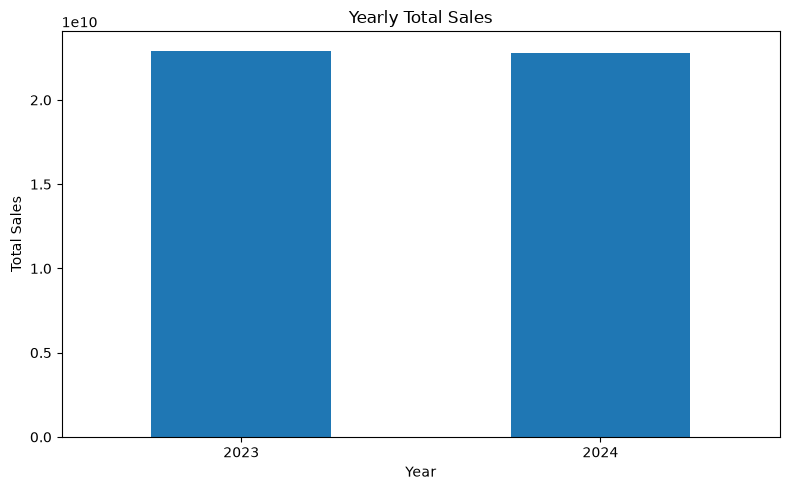

In [4]:
plt.figure(figsize=(8, 5))

yearly_sales.plot(kind='bar')

plt.title("Yearly Total Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
monthly_sales = (
    df.groupby(['Year', 'Month'])['Total_Sales']
    .sum()
    .reset_index()
)

monthly_sales['Year_Month'] = (
    monthly_sales['Year'].astype(str)
    + "-"
    + monthly_sales['Month'].astype(str).str.zfill(2)
)

print(monthly_sales.head())

   Year  Month   Total_Sales Year_Month
0  2023      1  2.030645e+09    2023-01
1  2023      2  1.756334e+09    2023-02
2  2023      3  1.918315e+09    2023-03
3  2023      4  1.895609e+09    2023-04
4  2023      5  1.913626e+09    2023-05


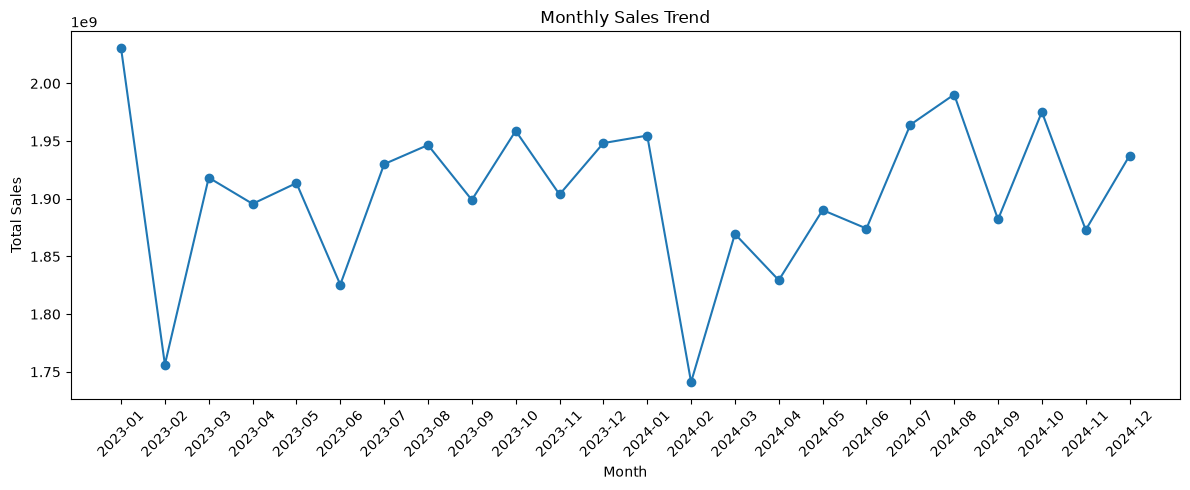

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['Year_Month'],
    monthly_sales['Total_Sales'],
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
category_sales = (
    df.groupby('Product_Category')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Product Category:")
print(category_sales)

Sales by Product Category:
Product_Category
Electronics        9.239969e+09
Home Appliances    9.179564e+09
Fashion            9.126091e+09
Groceries          9.095669e+09
Sports             9.066798e+09
Name: Total_Sales, dtype: float64


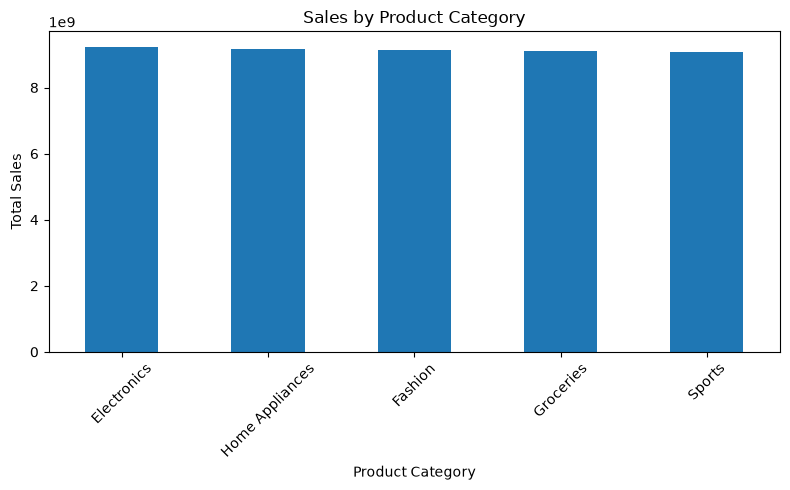

In [8]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
region_sales = (
    df.groupby('Region')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Region:")
print(region_sales)

Sales by Region:
Region
West     1.712281e+10
South    1.710938e+10
North    5.803047e+09
East     5.672850e+09
Name: Total_Sales, dtype: float64


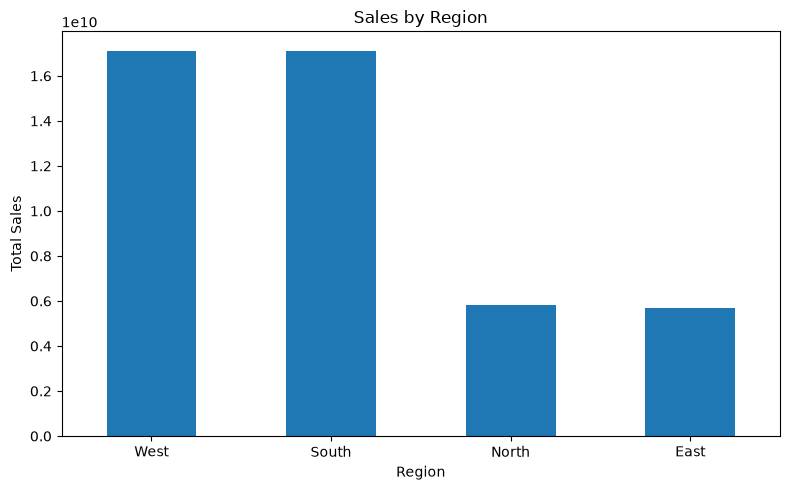

In [12]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
store_sales = (
    df.groupby('Store_Location')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Store Location:")
print(store_sales)

Sales by Store Location:
Store_Location
Delhi        5.803047e+09
Bangalore    5.758117e+09
Mumbai       5.751484e+09
Chennai      5.749821e+09
Pune         5.737160e+09
Kolkata      5.672850e+09
Ahmedabad    5.634170e+09
Hyderabad    5.601443e+09
Name: Total_Sales, dtype: float64


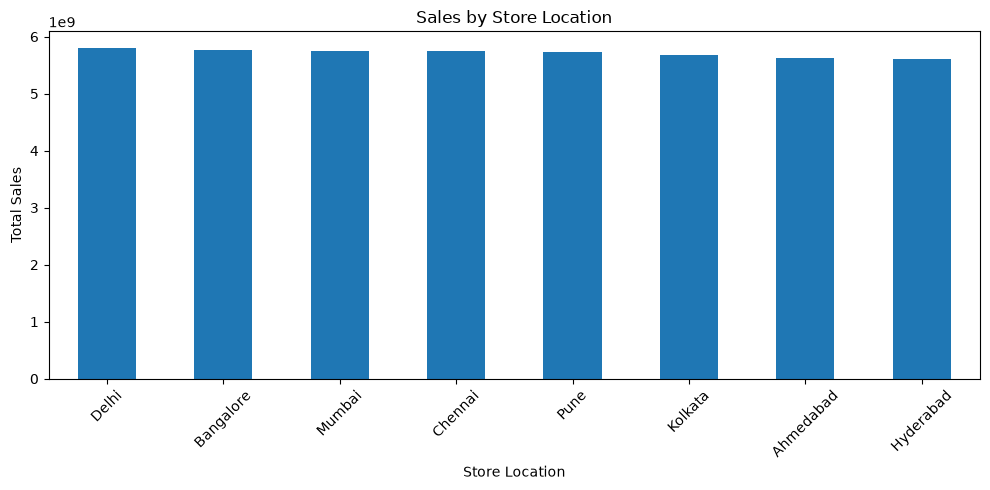

In [14]:
plt.figure(figsize=(10, 5))

store_sales.plot(kind='bar')

plt.title("Sales by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
customer_sales = (
    df.groupby('Customer_Type')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Customer Type:")
print(customer_sales)

Sales by Customer Type:
Customer_Type
Returning    2.739484e+10
New          1.831325e+10
Name: Total_Sales, dtype: float64


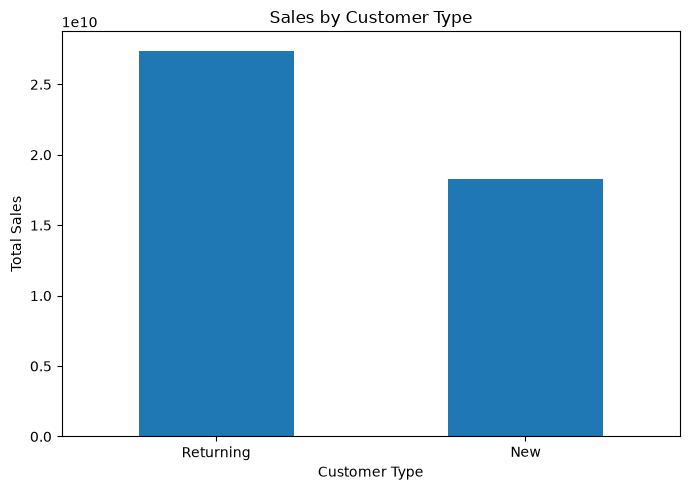

In [16]:
plt.figure(figsize=(7, 5))

customer_sales.plot(kind='bar')

plt.title("Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
payment_sales = (
    df.groupby('Payment_Mode')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Payment Mode:")
print(payment_sales)

Sales by Payment Mode:
Payment_Mode
Credit Card    1.155604e+10
Cash           1.141353e+10
Debit Card     1.139215e+10
UPI            1.134637e+10
Name: Total_Sales, dtype: float64


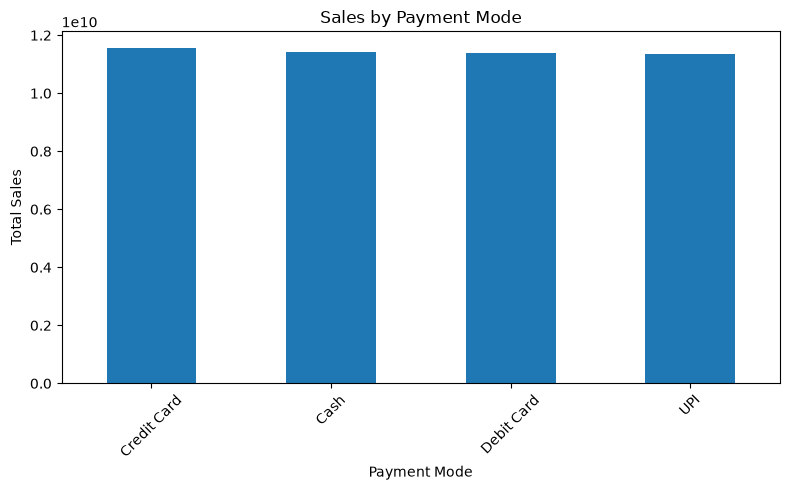

In [18]:
plt.figure(figsize=(8, 5))

payment_sales.plot(kind='bar')

plt.title("Sales by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
promotion_sales = (
    df.groupby('Promotion_Applied')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Promotion:")
print(promotion_sales)

Sales by Promotion:
Promotion_Applied
No     3.204533e+10
Yes    1.366276e+10
Name: Total_Sales, dtype: float64


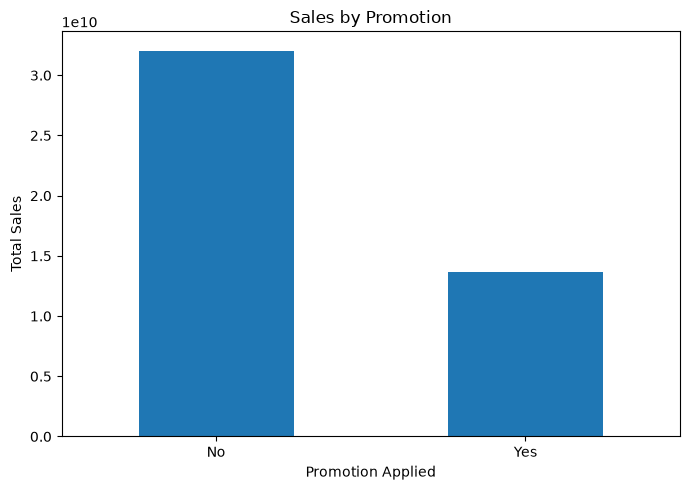

In [21]:
plt.figure(figsize=(7, 5))

promotion_sales.plot(kind='bar')

plt.title("Sales by Promotion")
plt.xlabel("Promotion Applied")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
holiday_sales = (
    df.groupby('Holiday_Flag')['Total_Sales']
    .sum()
)

print("Sales by Holiday Flag:")
print(holiday_sales)

Sales by Holiday Flag:
Holiday_Flag
0    4.515871e+10
1    5.493775e+08
Name: Total_Sales, dtype: float64


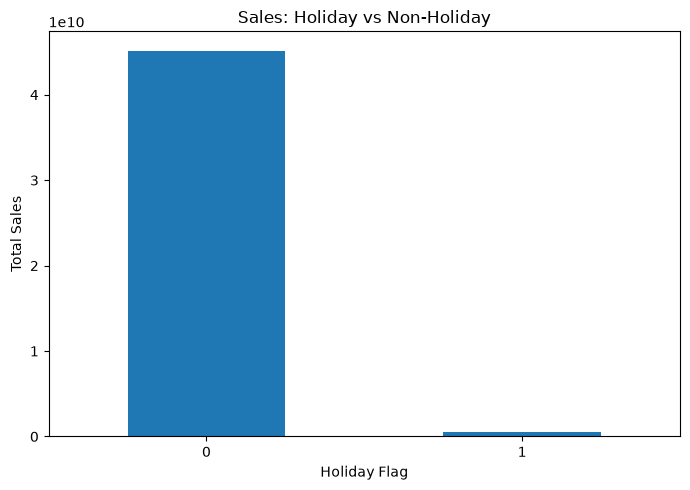

In [23]:
plt.figure(figsize=(7, 5))

holiday_sales.plot(kind='bar')

plt.title("Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday Flag")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
category_units = (
    df.groupby('Product_Category')['Units_Sold']
    .sum()
    .sort_values(ascending=False)
)

print("Units Sold by Product Category:")
print(category_units)

Units Sold by Product Category:
Product_Category
Electronics        367921
Home Appliances    365113
Sports             363129
Fashion            361431
Groceries          359711
Name: Units_Sold, dtype: int64


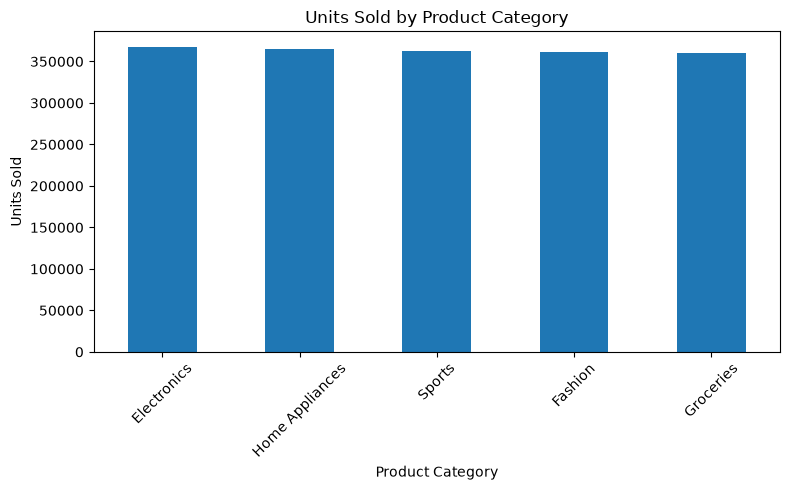

In [25]:
plt.figure(figsize=(8, 5))

category_units.plot(kind='bar')

plt.title("Units Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
category_revenue = (
    df.groupby('Product_Category')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by Product Category:")
print(category_revenue)

Revenue by Product Category:
Product_Category
Electronics        8.318539e+09
Home Appliances    8.262751e+09
Fashion            8.215645e+09
Groceries          8.170528e+09
Sports             8.166319e+09
Name: Revenue, dtype: float64


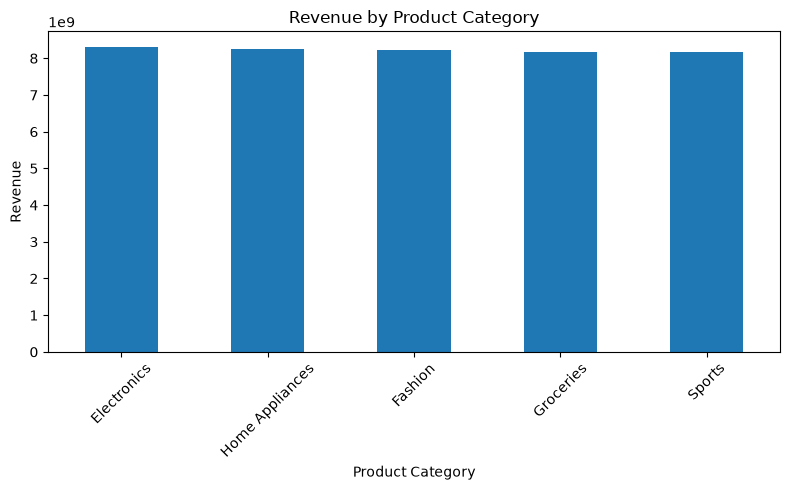

In [27]:
plt.figure(figsize=(8, 5))

category_revenue.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
brand_sales = (
    df.groupby('Brand')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
)

top_10_brands = brand_sales.head(10)

print("Top 10 Brands by Sales:")
print(top_10_brands)

Top 10 Brands by Sales:
Brand
Levis        2.375399e+09
Amul         2.350526e+09
OnePlus      2.324517e+09
Sony         2.317454e+09
LG           2.316646e+09
Philips      2.310796e+09
Samsung      2.310712e+09
Prestige     2.291204e+09
Apple        2.287286e+09
Decathlon    2.282927e+09
Name: Total_Sales, dtype: float64


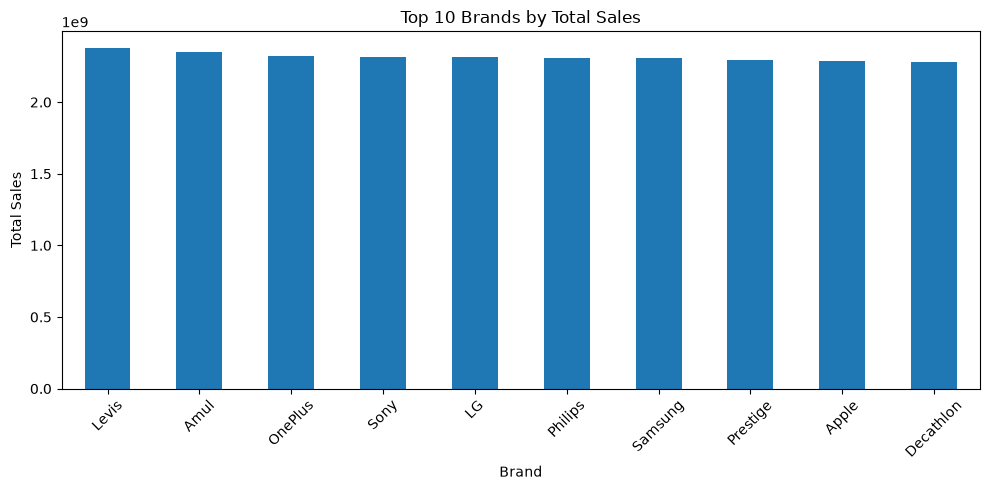

In [29]:
plt.figure(figsize=(10, 5))

top_10_brands.plot(kind='bar')

plt.title("Top 10 Brands by Total Sales")
plt.xlabel("Brand")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
product_sales = (
    df.groupby('Product_ID')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
)

top_10_products = product_sales.head(10)

print("Top 10 Products by Sales:")
print(top_10_products)

Top 10 Products by Sales:
Product_ID
PRD_713    74512291.35
PRD_379    73971268.03
PRD_632    68870752.06
PRD_279    67457863.92
PRD_727    64324657.73
PRD_197    64193969.34
PRD_828    63287015.77
PRD_602    63272084.41
PRD_900    62881379.06
PRD_528    62702061.49
Name: Total_Sales, dtype: float64


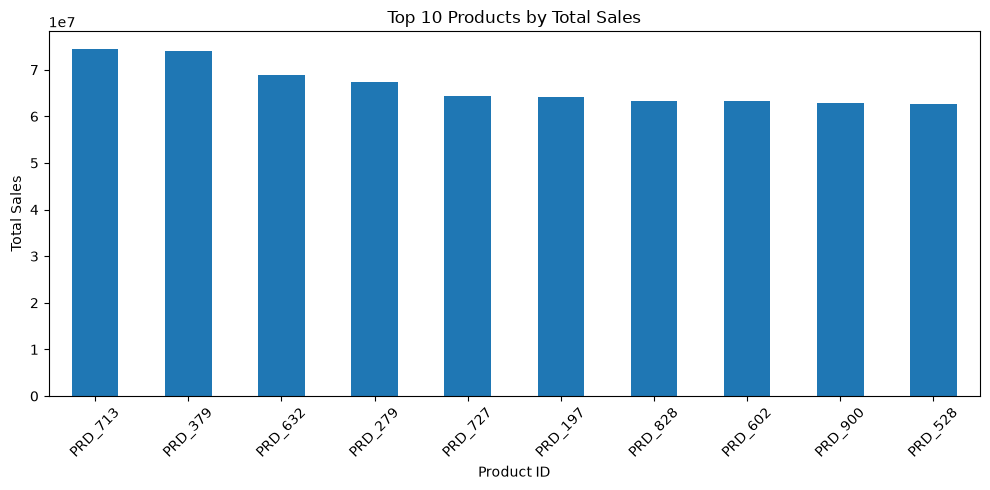

In [32]:
plt.figure(figsize=(10, 5))

top_10_products.plot(kind='bar')

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Product ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
rating_sales = (
    df.groupby('Store_Rating')['Total_Sales']
    .sum()
    .sort_index()
)

print("Sales by Store Rating:")
print(rating_sales)

Sales by Store Rating:
Store_Rating
3.5    1.495915e+09
3.6    3.029930e+09
3.7    3.114751e+09
3.8    3.092499e+09
3.9    2.989079e+09
4.0    3.034556e+09
4.1    3.084817e+09
4.2    3.012027e+09
4.3    3.030728e+09
4.4    3.018827e+09
4.5    3.034988e+09
4.6    3.015632e+09
4.7    3.087629e+09
4.8    3.061325e+09
4.9    3.017884e+09
5.0    1.587505e+09
Name: Total_Sales, dtype: float64


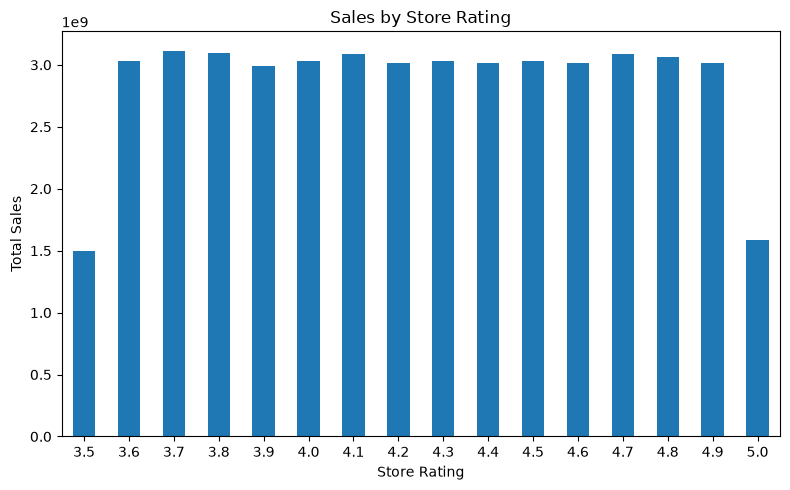

In [34]:
plt.figure(figsize=(8, 5))

rating_sales.plot(kind='bar')

plt.title("Sales by Store Rating")
plt.xlabel("Store Rating")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
discount_analysis = (
    df.groupby('Discount_Percentage')['Total_Sales']
    .mean()
)

print("Average Sales by Discount Percentage:")
print(discount_analysis)

Average Sales by Discount Percentage:
Discount_Percentage
0     627932.456272
5     623255.266778
10    625537.765654
15    630488.047071
20    623421.758021
Name: Total_Sales, dtype: float64


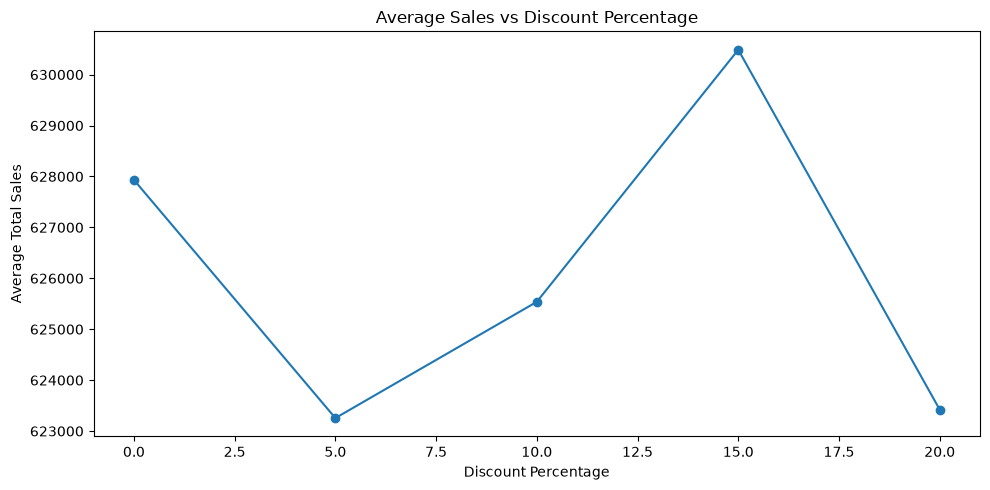

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    discount_analysis.index,
    discount_analysis.values,
    marker='o'
)

plt.title("Average Sales vs Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Average Total Sales")
plt.tight_layout()
plt.show()

In [37]:
stock_summary = df['Stock_On_Hand'].describe()

print("Stock on Hand Summary:")
print(stock_summary)

Stock on Hand Summary:
count    73000.000000
mean       274.624712
std        129.663977
min         50.000000
25%        162.000000
50%        274.000000
75%        387.000000
max        499.000000
Name: Stock_On_Hand, dtype: float64


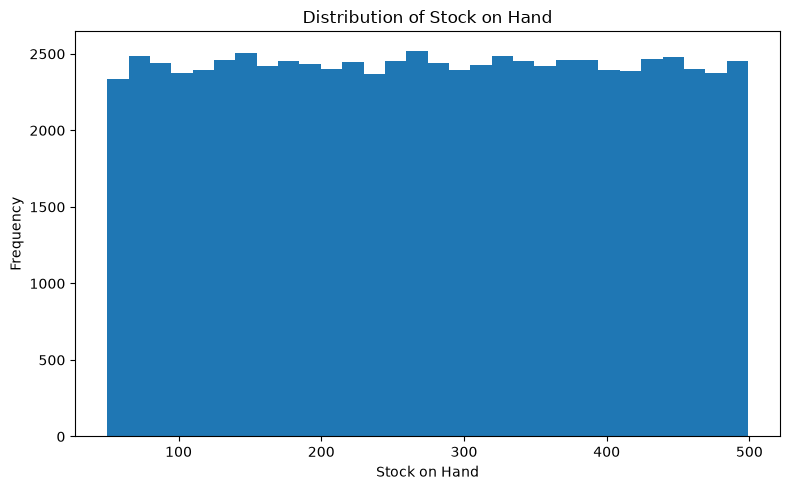

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(df['Stock_On_Hand'], bins=30)

plt.title("Distribution of Stock on Hand")
plt.xlabel("Stock on Hand")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [39]:
numeric_columns = [
    'Unit_Price',
    'Units_Sold',
    'Total_Sales',
    'Discount_Percentage',
    'Revenue',
    'Stock_On_Hand',
    'Store_Rating',
    'Holiday_Flag'
]

correlation_matrix = df[numeric_columns].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))

Correlation Matrix:
                     Unit_Price  Units_Sold  Total_Sales  Discount_Percentage  \
Unit_Price                 1.00        0.01         0.66                 0.00   
Units_Sold                 0.01        1.00         0.66                -0.00   
Total_Sales                0.66        0.66         1.00                -0.00   
Discount_Percentage        0.00       -0.00        -0.00                 1.00   
Revenue                    0.66        0.65         0.99                -0.09   
Stock_On_Hand             -0.00        0.00        -0.00                 0.01   
Store_Rating              -0.00        0.01         0.00                 0.00   
Holiday_Flag               0.00       -0.01        -0.00                -0.00   

                     Revenue  Stock_On_Hand  Store_Rating  Holiday_Flag  
Unit_Price              0.66          -0.00         -0.00          0.00  
Units_Sold              0.65           0.00          0.01         -0.01  
Total_Sales             0.99

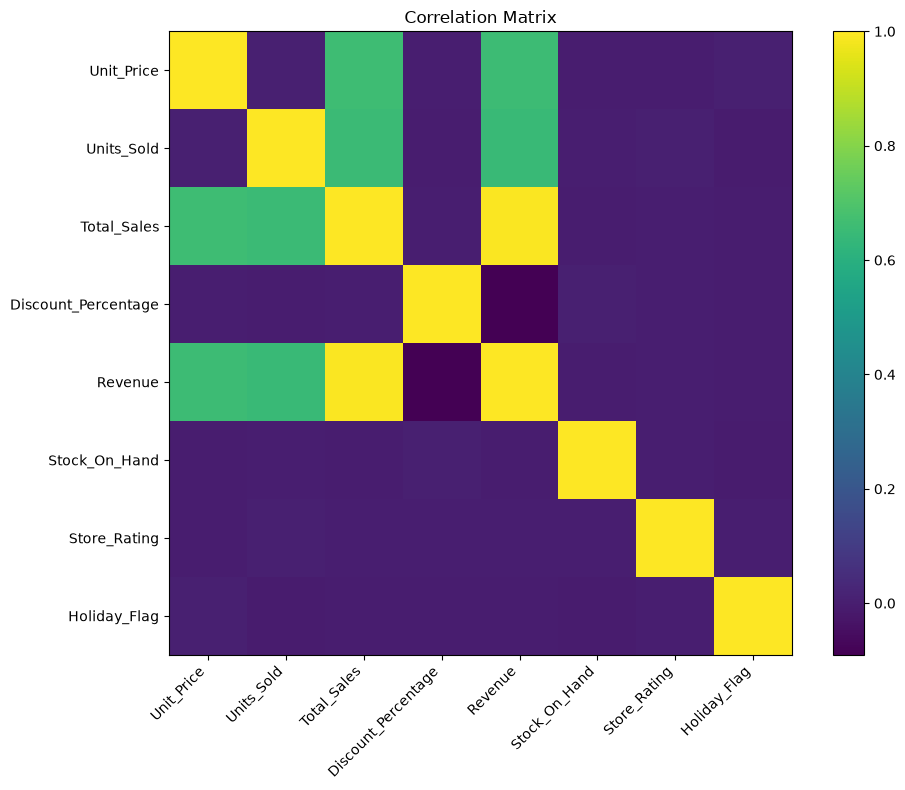

In [40]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, interpolation='nearest')
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()